In [58]:
# Cell 1 — Setup, project root discovery, imports

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt, resample_poly

# ---- find project root robustly ----
CWD = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "experiments").exists():
            return p
    raise FileNotFoundError("Project root not found. Expected folders: data/ and experiments/")

PROJECT_ROOT = find_project_root(CWD)
DATA_ROOT = PROJECT_ROOT / "data"
EXPERIMENTS_ROOT = PROJECT_ROOT / "experiments"
METADATA_PATH = DATA_ROOT / "metadata.csv"

# allow importing experiments/data_utils.py even if notebook is elsewhere
if str(EXPERIMENTS_ROOT) not in sys.path:
    sys.path.append(str(EXPERIMENTS_ROOT))

from data_utils import (
    load_metadata,
    get_record_row,
    resolve_record_path,
    load_record_array,
    decode_channel3,
)

FS_AUDIO = 4800
FS_MOTION = 100

PREP_CONFIG = {
    "audio_bp_lo": 60.0,
    "audio_bp_hi": 2200.0,
    "audio_filter_order": 4,
    "motion_lp_hi": 20.0,
    "motion_filter_order": 4,
}

print("CWD          :", CWD)
print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_ROOT    :", DATA_ROOT)
print("METADATA_PATH:", METADATA_PATH)

assert METADATA_PATH.exists(), f"metadata.csv not found: {METADATA_PATH}"

metadata_df = load_metadata(METADATA_PATH)
display(metadata_df.head())

CWD          : C:\Users\kiraz\OneDrive\Desktop\BOUN\Semester8(2025-2026)\EE492\experiments
PROJECT_ROOT : C:\Users\kiraz\OneDrive\Desktop\BOUN\Semester8(2025-2026)\EE492
DATA_ROOT    : C:\Users\kiraz\OneDrive\Desktop\BOUN\Semester8(2025-2026)\EE492\data
METADATA_PATH: C:\Users\kiraz\OneDrive\Desktop\BOUN\Semester8(2025-2026)\EE492\data\metadata.csv


,record_id,filename,date,subject,activity,context,relative_path
0,0,000_20250602_kivanc_standing_overclothes.csv,2025-06-02,kivanc,standing,overclothes,curated_csv/000_20250602_kivanc_standing_overc...
1,1,001_20250602_kivanc_sitting_overclothes.csv,2025-06-02,kivanc,sitting,overclothes,curated_csv/001_20250602_kivanc_sitting_overcl...
2,2,002_20250602_kivanc_sitting_overclothes.csv,2025-06-02,kivanc,sitting,overclothes,curated_csv/002_20250602_kivanc_sitting_overcl...
3,3,003_20250602_kivanc_walking_overclothes.csv,2025-06-02,kivanc,walking,overclothes,curated_csv/003_20250602_kivanc_walking_overcl...
4,4,004_20250602_kivanc_walking_overclothes.csv,2025-06-02,kivanc,walking,overclothes,curated_csv/004_20250602_kivanc_walking_overcl...


In [59]:
# Cell 2 — Simple and robust record path resolver

def resolve_record_path_safe(row):
    """
    Resolve one curated CSV path robustly.
    Priority:
    1) metadata['relative_path']
    2) metadata['filename']
    3) fallback to resolve_record_path(row)
    """
    candidates = []

    if "relative_path" in row and pd.notna(row["relative_path"]):
        rp = Path(str(row["relative_path"]).replace("\\", "/"))
        candidates += [
            PROJECT_ROOT / rp,
            DATA_ROOT / rp,
        ]

    if "filename" in row and pd.notna(row["filename"]):
        fn = Path(str(row["filename"])).name
        candidates += [
            DATA_ROOT / "curated_csv" / fn,
        ]

    try:
        p = Path(str(resolve_record_path(row)).replace("\\", "/"))
        if p.is_absolute():
            candidates.append(p)
        else:
            candidates += [
                PROJECT_ROOT / p,
                DATA_ROOT / p,
                DATA_ROOT / "curated_csv" / p.name,
            ]
    except Exception:
        pass

    seen = set()
    for c in candidates:
        c = c.resolve()
        if str(c) in seen:
            continue
        seen.add(str(c))
        if c.exists():
            return c

    raise FileNotFoundError(
        f"Could not resolve record path for record_id={row.get('record_id', 'unknown')}"
    )


def load_raw_record(record_id, metadata_df):
    row = get_record_row(metadata_df, record_id)
    record_path = resolve_record_path_safe(row)
    x = load_record_array(record_path)

    if not (x.ndim == 2 and x.shape[1] == 4):
        raise ValueError(f"Expected shape (T, 4), got {x.shape}")

    pulm_raw = x[:, 0].astype(np.float32)
    amb_raw = x[:, 1].astype(np.float32)
    stretch_raw, cough_label = decode_channel3(x[:, 2])
    stretch_raw = stretch_raw.astype(np.float32)
    cough_label = cough_label.astype(np.uint8)
    accz_raw = x[:, 3].astype(np.float32)

    t_audio = np.arange(len(pulm_raw), dtype=np.float32) / FS_AUDIO

    return {
        "record_id": row["record_id"],
        "record_path": record_path,
        "t_audio": t_audio,
        "pulm_raw": pulm_raw,
        "amb_raw": amb_raw,
        "stretch_raw_4800": stretch_raw,
        "accz_raw_4800": accz_raw,
        "cough_label_4800": cough_label,
    }

In [60]:
# Cell 3 — Preprocessing

_PREPROCESSED_CACHE = {}

def _butter_bandpass_sos(low_hz, high_hz, fs, order=4):
    return butter(order, [low_hz, high_hz], btype="bandpass", fs=fs, output="sos")

def _butter_lowpass_sos(high_hz, fs, order=4):
    return butter(order, high_hz, btype="lowpass", fs=fs, output="sos")

def load_record_preprocessed(record_id, metadata_df, use_cache=True):
    cache_key = str(record_id)
    if use_cache and cache_key in _PREPROCESSED_CACHE:
        return _PREPROCESSED_CACHE[cache_key]

    raw = load_raw_record(record_id, metadata_df)

    pulm_raw = raw["pulm_raw"]
    amb_raw = raw["amb_raw"]
    stretch_raw = raw["stretch_raw_4800"]
    accz_raw = raw["accz_raw_4800"]
    cough_label = raw["cough_label_4800"]

    audio_sos = _butter_bandpass_sos(
        PREP_CONFIG["audio_bp_lo"],
        PREP_CONFIG["audio_bp_hi"],
        fs=FS_AUDIO,
        order=PREP_CONFIG["audio_filter_order"],
    )

    pulm_bp = sosfiltfilt(audio_sos, pulm_raw - np.median(pulm_raw)).astype(np.float32)
    amb_bp = sosfiltfilt(audio_sos, amb_raw - np.median(amb_raw)).astype(np.float32)

    stretch_centered = stretch_raw - np.median(stretch_raw)
    stretch_rs = resample_poly(stretch_centered, up=FS_MOTION, down=FS_AUDIO).astype(np.float32)
    accz_rs = resample_poly(accz_raw, up=FS_MOTION, down=FS_AUDIO).astype(np.float32)

    motion_sos = _butter_lowpass_sos(
        PREP_CONFIG["motion_lp_hi"],
        fs=FS_MOTION,
        order=PREP_CONFIG["motion_filter_order"],
    )

    stretch_lp = sosfiltfilt(motion_sos, stretch_rs).astype(np.float32)
    accz_lp = sosfiltfilt(motion_sos, accz_rs).astype(np.float32)

    out = {
        **raw,
        "t_motion": np.arange(len(stretch_lp), dtype=np.float32) / FS_MOTION,
        "pulm_bp": pulm_bp,
        "amb_bp": amb_bp,
        "stretch_lp": stretch_lp,
        "accz_lp": accz_lp,
    }

    if use_cache:
        _PREPROCESSED_CACHE[cache_key] = out

    return out

In [61]:
# Cell 4 — Fixed plotting (centered and scaled to [-1, 1])

def _center_and_scale_unit(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    m = np.max(np.abs(x))
    if m < 1e-8:
        return np.zeros_like(x)
    return x / m


def plot_raw_record(record_id, metadata_df, t_start=None, t_end=None):
    rec = load_raw_record(record_id, metadata_df)

    t = rec["t_audio"]
    i0 = 0 if t_start is None else max(0, int(t_start * FS_AUDIO))
    i1 = len(t) if t_end is None else min(len(t), int(t_end * FS_AUDIO))
    tt = t[i0:i1]

    fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True)

    axes[0].plot(tt, rec["pulm_raw"][i0:i1], lw=0.8)
    axes[0].set_title("Raw Pulmonary Mic")
    axes[0].set_ylabel("ADC Value")

    axes[1].plot(tt, rec["amb_raw"][i0:i1], lw=0.8)
    axes[1].set_title("Raw Ambient Mic")
    axes[1].set_ylabel("ADC Value")

    axes[2].plot(tt, rec["stretch_raw_4800"][i0:i1], lw=0.8)
    axes[2].set_title("Raw Stretch Sensor")
    axes[2].set_ylabel("ADC Value")

    axes[3].plot(tt, rec["accz_raw_4800"][i0:i1], lw=0.8)
    axes[3].set_title("Raw Z-Axis Accelerometer")
    axes[3].set_ylabel("ADC Value")

    axes[4].fill_between(tt, 0, rec["cough_label_4800"][i0:i1], step="pre", alpha=0.35)
    axes[4].set_title("Cough Label")
    axes[4].set_ylabel("Logic")
    axes[4].set_xlabel("Time (s)")
    axes[4].set_ylim(-0.05, 1.1)

    plt.tight_layout()
    plt.show()


def plot_preprocessed_record(record_id, metadata_df, t_start=None, t_end=None):
    rec = load_record_preprocessed(record_id, metadata_df, use_cache=True)

    t_audio = rec["t_audio"]
    t_motion = rec["t_motion"]

    ia0 = 0 if t_start is None else max(0, int(t_start * FS_AUDIO))
    ia1 = len(t_audio) if t_end is None else min(len(t_audio), int(t_end * FS_AUDIO))

    im0 = 0 if t_start is None else max(0, int(t_start * FS_MOTION))
    im1 = len(t_motion) if t_end is None else min(len(t_motion), int(t_end * FS_MOTION))

    # raw motion -> 100 Hz only for visual comparison
    stretch_raw_rs = resample_poly(rec["stretch_raw_4800"], up=FS_MOTION, down=FS_AUDIO).astype(np.float32)
    accz_raw_rs = resample_poly(rec["accz_raw_4800"], up=FS_MOTION, down=FS_AUDIO).astype(np.float32)

    # avoid edge artifacts
    motion_trim = 2
    im0_safe = max(im0, motion_trim)
    im1_safe = max(im0_safe + 1, min(im1, len(t_motion) - motion_trim))

    n_stretch = min(len(t_motion), len(stretch_raw_rs), len(rec["stretch_lp"]))
    n_accz = min(len(t_motion), len(accz_raw_rs), len(rec["accz_lp"]))

    s1_end = min(im1_safe, n_stretch)
    s2_end = min(im1_safe, n_accz)

    fig, axes = plt.subplots(5, 1, figsize=(16, 9), sharex=True)

    # audio
    axes[0].plot(
        t_audio[ia0:ia1],
        _center_and_scale_unit(rec["pulm_raw"][ia0:ia1]),
        lw=0.8,
        color="gray",
        alpha=0.45
    )
    axes[0].plot(
        t_audio[ia0:ia1],
        _center_and_scale_unit(rec["pulm_bp"][ia0:ia1]),
        lw=1.1,
        color="blue"
    )
    axes[0].set_title("Pulmonary (Overlay)")
    axes[0].set_ylim(-1.05, 1.05)

    axes[1].plot(
        t_audio[ia0:ia1],
        _center_and_scale_unit(rec["amb_raw"][ia0:ia1]),
        lw=0.8,
        color="gray",
        alpha=0.45
    )
    axes[1].plot(
        t_audio[ia0:ia1],
        _center_and_scale_unit(rec["amb_bp"][ia0:ia1]),
        lw=1.1,
        color="red"
    )
    axes[1].set_title("Ambient (Overlay)")
    axes[1].set_ylim(-1.05, 1.05)

    # stretch
    axes[2].plot(
        t_motion[im0_safe:s1_end],
        _center_and_scale_unit(stretch_raw_rs[im0_safe:s1_end]),
        lw=0.8,
        color="gray",
        alpha=0.45
    )
    axes[2].plot(
        t_motion[im0_safe:s1_end],
        _center_and_scale_unit(rec["stretch_lp"][im0_safe:s1_end]),
        lw=1.1,
        color="magenta"
    )
    axes[2].set_title("Stretch (Overlay)")
    axes[2].set_ylim(-1.05, 1.05)

    # acc z
    axes[3].plot(
        t_motion[im0_safe:s2_end],
        _center_and_scale_unit(accz_raw_rs[im0_safe:s2_end]),
        lw=0.8,
        color="gray",
        alpha=0.45
    )
    axes[3].plot(
        t_motion[im0_safe:s2_end],
        _center_and_scale_unit(rec["accz_lp"][im0_safe:s2_end]),
        lw=1.1,
        color="limegreen"
    )
    axes[3].set_title("Acc Z (Overlay)")
    axes[3].set_ylim(-1.05, 1.05)

    # label
    axes[4].fill_between(
        t_audio[ia0:ia1],
        0,
        rec["cough_label_4800"][ia0:ia1],
        step="pre",
        alpha=0.35,
        color="gray"
    )
    axes[4].set_title("Ground Truth Label")
    axes[4].set_ylim(-0.05, 1.1)
    axes[4].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

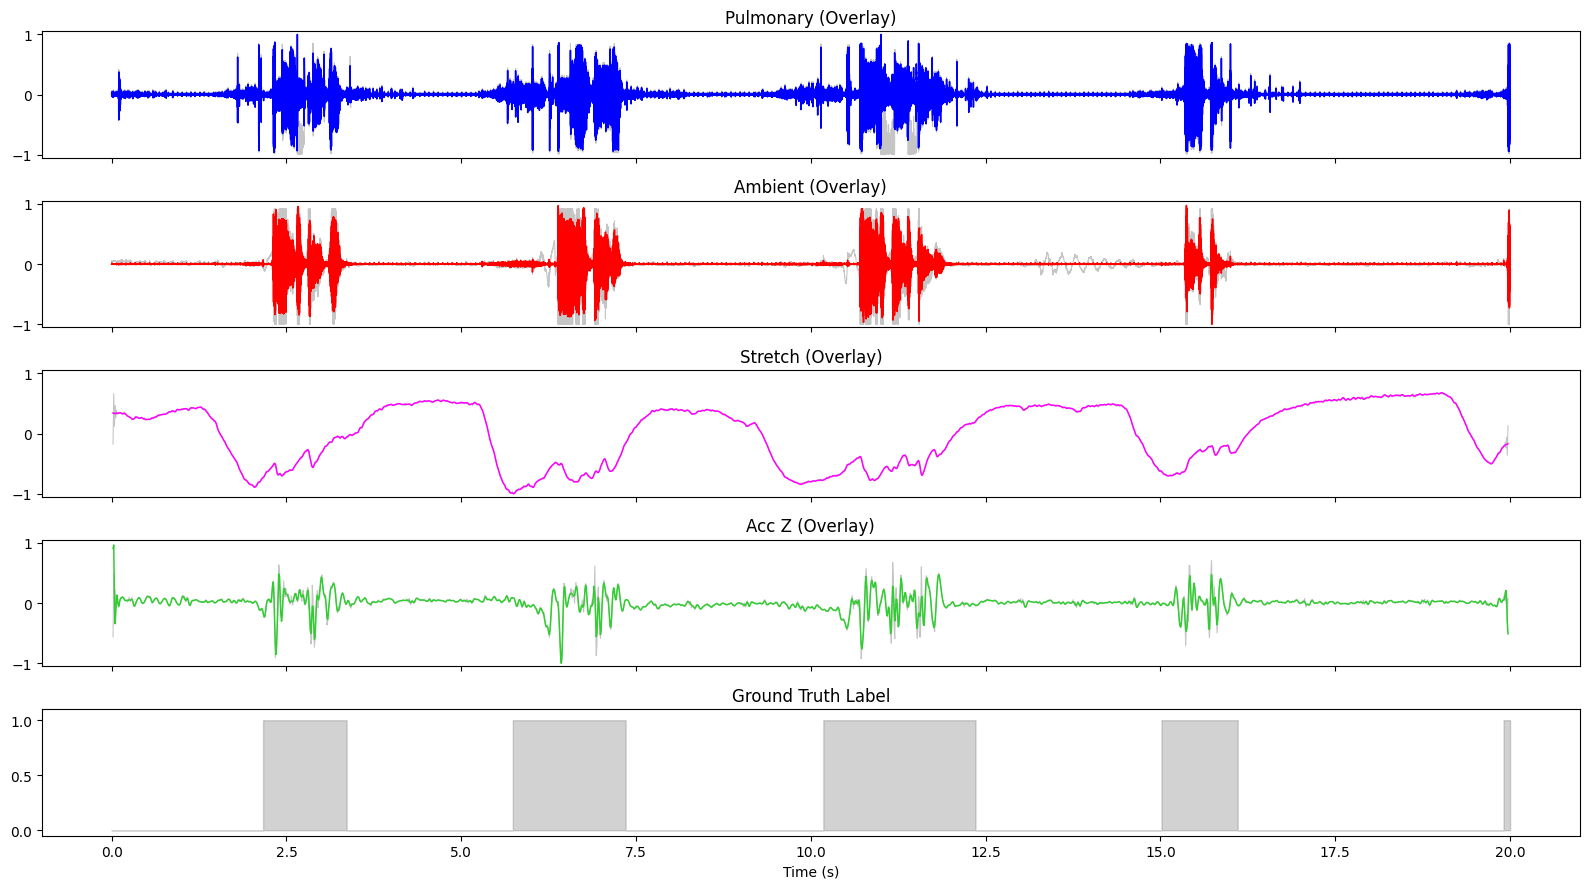

In [62]:
plot_preprocessed_record(example_record_id, metadata_df)

In [63]:
# Cell 5 — Time-aligned window extractor

WIN_SEC = 0.5

def extract_aligned_window(rec, start_sec, win_sec=WIN_SEC):
    """
    Extract one time-aligned window from a preprocessed record.

    Returns:
        pulm_win      : (Ta,)
        amb_win       : (Ta,)
        stretch_win   : (Tm,)
        accz_win      : (Tm,)
        label_win     : (Ta,)
        meta dict
    """
    fs_a = FS_AUDIO
    fs_m = FS_MOTION

    n_a = int(round(win_sec * fs_a))
    n_m = int(round(win_sec * fs_m))

    a0 = int(round(start_sec * fs_a))
    a1 = a0 + n_a

    m0 = int(round(start_sec * fs_m))
    m1 = m0 + n_m

    if a0 < 0 or m0 < 0:
        raise ValueError("start_sec must be non-negative")

    if a1 > len(rec["pulm_bp"]) or a1 > len(rec["amb_bp"]) or a1 > len(rec["cough_label_4800"]):
        raise ValueError("Audio window exceeds record boundary")

    if m1 > len(rec["stretch_lp"]) or m1 > len(rec["accz_lp"]):
        raise ValueError("Motion window exceeds record boundary")

    pulm_win = rec["pulm_bp"][a0:a1]
    amb_win = rec["amb_bp"][a0:a1]
    stretch_win = rec["stretch_lp"][m0:m1]
    accz_win = rec["accz_lp"][m0:m1]
    label_win = rec["cough_label_4800"][a0:a1]

    meta = {
        "record_id": rec["record_id"],
        "start_sec": start_sec,
        "end_sec": start_sec + win_sec,
        "n_audio": len(pulm_win),
        "n_motion": len(stretch_win),
        "has_cough": int(label_win.max() > 0),
        "cough_ratio": float(label_win.mean()),
    }

    return pulm_win, amb_win, stretch_win, accz_win, label_win, meta

In [64]:
# Cell 6 — Test one window

rec0 = load_record_preprocessed(example_record_id, metadata_df)

pulm_w, amb_w, stretch_w, accz_w, label_w, meta_w = extract_aligned_window(
    rec0,
    start_sec=10.0,
    win_sec=1.0
)

print(meta_w)
print("pulm   :", pulm_w.shape)
print("amb    :", amb_w.shape)
print("stretch:", stretch_w.shape)
print("accz   :", accz_w.shape)
print("label  :", label_w.shape)

{'record_id': np.int64(0), 'start_sec': 10.0, 'end_sec': 11.0, 'n_audio': 4800, 'n_motion': 100, 'has_cough': 1, 'cough_ratio': 0.82125}
pulm   : (4800,)
amb    : (4800,)
stretch: (100,)
accz   : (100,)
label  : (4800,)


In [65]:
# Cell 9 — Better visualization scaling + fixed Acc Z plotting

WINDOW_SEC = 0.30
STRIDE_SEC = 0.15
POS_LABEL_MODE = "any"


def _robust_unit_scale(x, q=99.0):
    """
    Center signal and scale it to roughly [-1, 1] using a robust percentile
    instead of max(abs(.)), so a few spikes do not flatten the whole signal.
    """
    x = np.asarray(x, dtype=np.float32)
    x = x - np.median(x)

    s = np.percentile(np.abs(x), q)
    if s < 1e-8:
        return np.zeros_like(x)

    x = x / s
    x = np.clip(x, -1.0, 1.0)
    return x


def build_windows_for_one_record(rec, window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC, pos_label_mode=POS_LABEL_MODE):
    total_dur_sec = min(
        len(rec["pulm_bp"]) / FS_AUDIO,
        len(rec["amb_bp"]) / FS_AUDIO,
        len(rec["cough_label_4800"]) / FS_AUDIO,
        len(rec["stretch_lp"]) / FS_MOTION,
        len(rec["accz_lp"]) / FS_MOTION,
    )

    starts = np.arange(0, total_dur_sec - window_sec + 1e-9, stride_sec, dtype=np.float32)

    rows = []
    for s in starts:
        _, _, _, _, label_w, meta_w = extract_aligned_window(rec, float(s), win_sec=window_sec)

        if pos_label_mode == "any":
            y = int(label_w.max() > 0)
        elif pos_label_mode == "majority":
            y = int(label_w.mean() >= 0.5)
        else:
            raise ValueError("pos_label_mode must be 'any' or 'majority'")

        rows.append({
            "record_id": int(rec["record_id"]),
            "start_sec": float(meta_w["start_sec"]),
            "end_sec": float(meta_w["end_sec"]),
            "has_cough_window": y,
            "cough_ratio": float(meta_w["cough_ratio"]),
        })

    return pd.DataFrame(rows)


def plot_record_with_window_labels(record_id, metadata_df, window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC, pos_label_mode=POS_LABEL_MODE):
    rec = load_record_preprocessed(record_id, metadata_df, use_cache=True)
    win_df = build_windows_for_one_record(rec, window_sec=window_sec, stride_sec=stride_sec, pos_label_mode=pos_label_mode)

    t_audio = rec["t_audio"]
    t_motion = rec["t_motion"]

    # motion raw -> 100 Hz only for overlay
    stretch_raw_rs = resample_poly(rec["stretch_raw_4800"], up=FS_MOTION, down=FS_AUDIO).astype(np.float32)
    accz_raw_rs = resample_poly(rec["accz_raw_4800"], up=FS_MOTION, down=FS_AUDIO).astype(np.float32)

    n_stretch = min(len(t_motion), len(stretch_raw_rs), len(rec["stretch_lp"]))
    n_accz = min(len(t_motion), len(accz_raw_rs), len(rec["accz_lp"]))

    # trim a few motion samples from both ends to avoid edge artifacts
    trim_m = 2
    sm0 = trim_m
    sm1 = max(sm0 + 1, n_stretch - trim_m)
    am0 = trim_m
    am1 = max(am0 + 1, n_accz - trim_m)

    fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_audio, _robust_unit_scale(rec["pulm_raw"]), lw=0.7, color="gray", alpha=0.35)
    axes[0].plot(t_audio, _robust_unit_scale(rec["pulm_bp"]), lw=1.0, color="blue")
    axes[0].set_title("Pulmonary (Overlay)")
    axes[0].set_ylim(-1.05, 1.05)

    axes[1].plot(t_audio, _robust_unit_scale(rec["amb_raw"]), lw=0.7, color="gray", alpha=0.35)
    axes[1].plot(t_audio, _robust_unit_scale(rec["amb_bp"]), lw=1.0, color="red")
    axes[1].set_title("Ambient (Overlay)")
    axes[1].set_ylim(-1.05, 1.05)

    axes[2].plot(
        t_motion[sm0:sm1],
        _robust_unit_scale(stretch_raw_rs[sm0:sm1]),
        lw=0.7,
        color="gray",
        alpha=0.35
    )
    axes[2].plot(
        t_motion[sm0:sm1],
        _robust_unit_scale(rec["stretch_lp"][sm0:sm1]),
        lw=1.0,
        color="magenta"
    )
    axes[2].set_title("Stretch (Overlay)")
    axes[2].set_ylim(-1.05, 1.05)

    axes[3].plot(
        t_motion[am0:am1],
        _robust_unit_scale(accz_raw_rs[am0:am1]),
        lw=0.7,
        color="gray",
        alpha=0.35
    )
    axes[3].plot(
        t_motion[am0:am1],
        _robust_unit_scale(rec["accz_lp"][am0:am1]),
        lw=1.0,
        color="limegreen"
    )
    axes[3].set_title("Acc Z (Overlay)")
    axes[3].set_ylim(-1.05, 1.05)

    axes[4].fill_between(t_audio, 0, rec["cough_label_4800"], step="pre", color="gray", alpha=0.35)
    axes[4].set_title("Ground Truth Label")
    axes[4].set_ylim(-0.05, 1.1)

    for _, row in win_df.iterrows():
        if row["has_cough_window"] == 1:
            axes[5].axvspan(row["start_sec"], row["end_sec"], color="tab:orange", alpha=0.30)

    axes[5].set_title(
        f'Window Builder Labels | win={window_sec:.2f}s | stride={stride_sec:.2f}s | mode="{pos_label_mode}"'
    )
    axes[5].set_ylim(0, 1)
    axes[5].set_yticks([])
    axes[5].set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

    return win_df

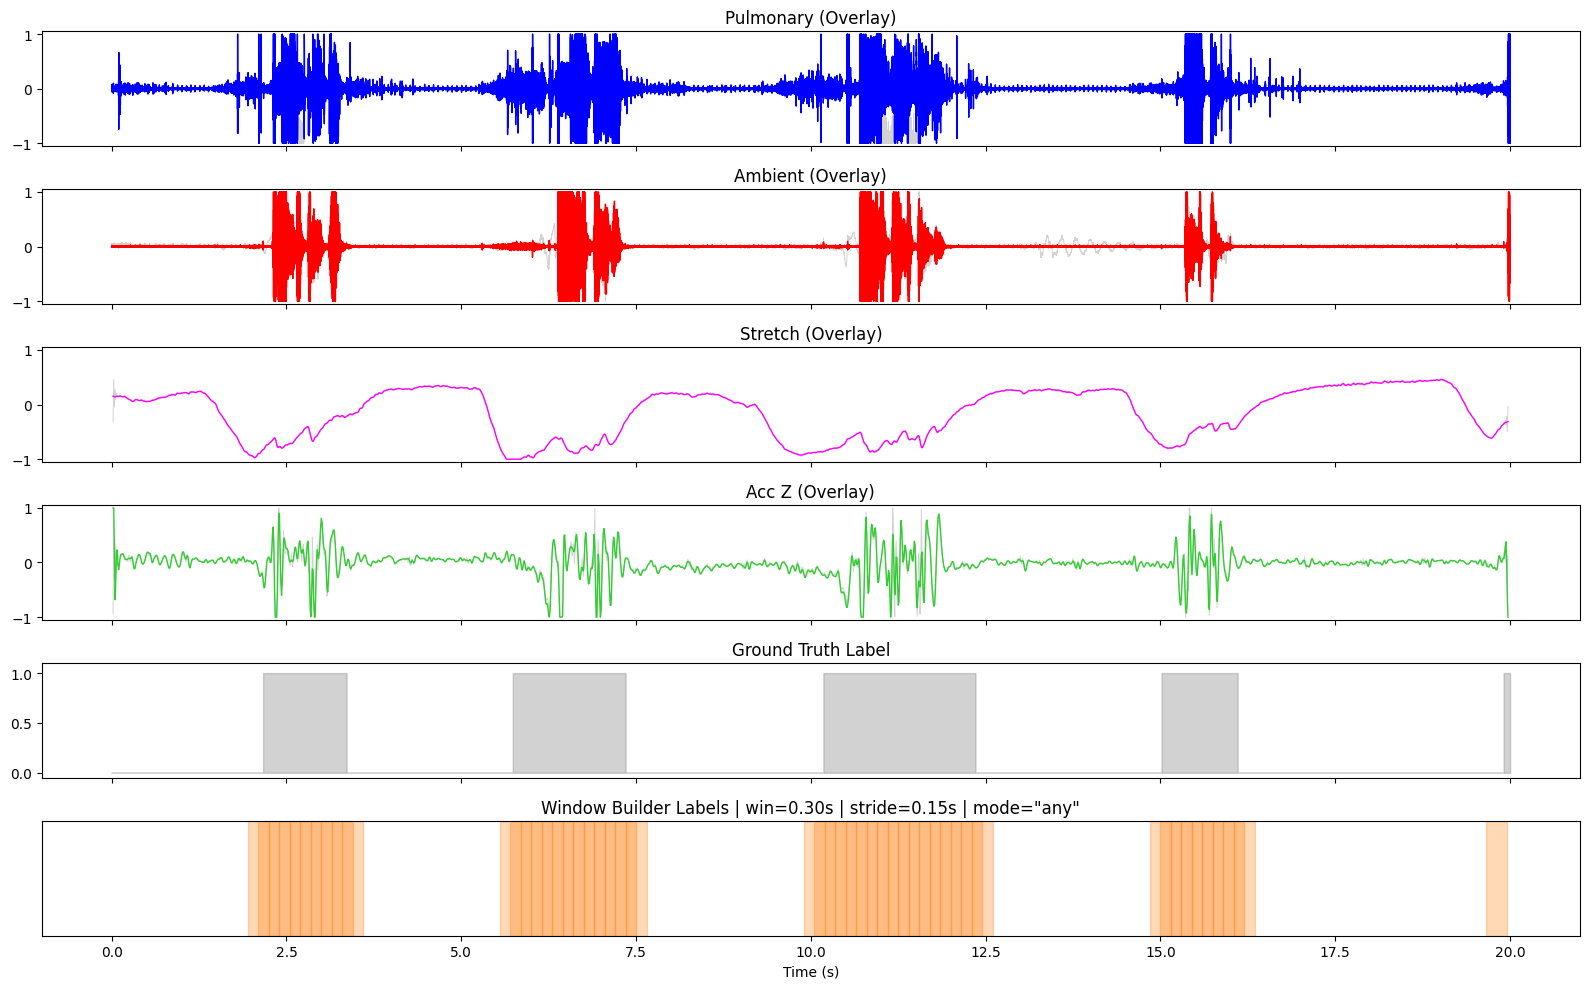

In [66]:
win_df1 = plot_record_with_window_labels(
    example_record_id,
    metadata_df,
    window_sec=0.30,
    stride_sec=0.15,
    pos_label_mode="any"
)

In [67]:
# Cell 10 — Inspect one-record window table and basic counts

def summarize_one_record_windows(win_df):
    n_total = len(win_df)
    n_pos = int(win_df["has_cough_window"].sum())
    n_neg = int(n_total - n_pos)

    print(f"total windows : {n_total}")
    print(f"positive      : {n_pos}")
    print(f"negative      : {n_neg}")
    print(f"positive ratio: {n_pos / n_total:.3f}")

    display(win_df.head(10))
    display(win_df[win_df["has_cough_window"] == 1].head(10))
    display(win_df[win_df["has_cough_window"] == 0].head(10))


summarize_one_record_windows(win_df1)

total windows : 132
positive      : 50
negative      : 82
positive ratio: 0.379


,record_id,start_sec,end_sec,has_cough_window,cough_ratio
0,0,0.00,0.30,0,0.0
1,0,0.15,0.45,0,0.0
2,0,0.30,0.60,0,0.0
3,0,0.45,0.75,0,0.0
4,0,0.60,0.90,0,0.0
5,0,0.75,1.05,0,0.0
6,0,0.90,1.20,0,0.0
7,0,1.05,1.35,0,0.0
8,0,1.20,1.50,0,0.0
9,0,1.35,1.65,0,0.0


,record_id,start_sec,end_sec,has_cough_window,cough_ratio
13,0,1.95,2.25,1,0.279861
14,0,2.10,2.40,1,0.779861
15,0,2.25,2.55,1,1.000000
16,0,2.40,2.70,1,1.000000
17,0,2.55,2.85,1,1.000000
18,0,2.70,3.00,1,1.000000
19,0,2.85,3.15,1,1.000000
20,0,3.00,3.30,1,1.000000
21,0,3.15,3.45,1,0.702083
22,0,3.30,3.60,1,0.202083


,record_id,start_sec,end_sec,has_cough_window,cough_ratio
0,0,0.00,0.30,0,0.0
1,0,0.15,0.45,0,0.0
2,0,0.30,0.60,0,0.0
3,0,0.45,0.75,0,0.0
4,0,0.60,0.90,0,0.0
5,0,0.75,1.05,0,0.0
6,0,0.90,1.20,0,0.0
7,0,1.05,1.35,0,0.0
8,0,1.20,1.50,0,0.0
9,0,1.35,1.65,0,0.0


In [68]:
# Cell 11 — Build full window dataset for one record

WINDOW_SEC = 0.30
STRIDE_SEC = 0.15
POS_LABEL_MODE = "any"


def label_window_from_samples(label_w, mode="any"):
    if mode == "any":
        return int(np.max(label_w) > 0)
    elif mode == "majority":
        return int(np.mean(label_w) >= 0.5)
    else:
        raise ValueError("mode must be 'any' or 'majority'")


def build_window_dataset_one_record(
    rec,
    window_sec=WINDOW_SEC,
    stride_sec=STRIDE_SEC,
    pos_label_mode=POS_LABEL_MODE,
):
    """
    Build a full window dataset for one preprocessed record.

    Returns:
        X_dict:
            {
              "pulm":    (N, Ta),
              "amb":     (N, Ta),
              "stretch": (N, Tm),
              "accz":    (N, Tm),
            }
        y:      (N,)
        meta_df: one row per window
    """
    total_dur_sec = min(
        len(rec["pulm_bp"]) / FS_AUDIO,
        len(rec["amb_bp"]) / FS_AUDIO,
        len(rec["cough_label_4800"]) / FS_AUDIO,
        len(rec["stretch_lp"]) / FS_MOTION,
        len(rec["accz_lp"]) / FS_MOTION,
    )

    starts = np.arange(0, total_dur_sec - window_sec + 1e-9, stride_sec, dtype=np.float32)

    pulm_list = []
    amb_list = []
    stretch_list = []
    accz_list = []
    y_list = []
    meta_rows = []

    for s in starts:
        pulm_w, amb_w, stretch_w, accz_w, label_w, meta_w = extract_aligned_window(
            rec,
            start_sec=float(s),
            win_sec=window_sec,
        )

        y = label_window_from_samples(label_w, mode=pos_label_mode)

        pulm_list.append(pulm_w.astype(np.float32))
        amb_list.append(amb_w.astype(np.float32))
        stretch_list.append(stretch_w.astype(np.float32))
        accz_list.append(accz_w.astype(np.float32))
        y_list.append(y)

        meta_rows.append({
            "record_id": int(meta_w["record_id"]),
            "start_sec": float(meta_w["start_sec"]),
            "end_sec": float(meta_w["end_sec"]),
            "has_cough_window": int(y),
            "cough_ratio": float(meta_w["cough_ratio"]),
            "n_audio": int(meta_w["n_audio"]),
            "n_motion": int(meta_w["n_motion"]),
        })

    X_dict = {
        "pulm": np.stack(pulm_list, axis=0),
        "amb": np.stack(amb_list, axis=0),
        "stretch": np.stack(stretch_list, axis=0),
        "accz": np.stack(accz_list, axis=0),
    }
    y = np.asarray(y_list, dtype=np.int64)
    meta_df = pd.DataFrame(meta_rows)

    return X_dict, y, meta_df

In [69]:
# Cell 12 — Run one-record builder and inspect outputs

rec0 = load_record_preprocessed(example_record_id, metadata_df)

X0, y0, meta0 = build_window_dataset_one_record(
    rec0,
    window_sec=0.30,
    stride_sec=0.15,
    pos_label_mode="any",
)

print("Shapes")
print("pulm   :", X0["pulm"].shape)
print("amb    :", X0["amb"].shape)
print("stretch:", X0["stretch"].shape)
print("accz   :", X0["accz"].shape)
print("y      :", y0.shape)

print("\nLabel counts")
print("positive:", int(y0.sum()))
print("negative:", int((y0 == 0).sum()))

display(meta0.head(10))

Shapes
pulm   : (132, 1440)
amb    : (132, 1440)
stretch: (132, 30)
accz   : (132, 30)
y      : (132,)

Label counts
positive: 50
negative: 82


,record_id,start_sec,end_sec,has_cough_window,cough_ratio,n_audio,n_motion
0,0,0.00,0.30,0,0.0,1440,30
1,0,0.15,0.45,0,0.0,1440,30
2,0,0.30,0.60,0,0.0,1440,30
3,0,0.45,0.75,0,0.0,1440,30
4,0,0.60,0.90,0,0.0,1440,30
5,0,0.75,1.05,0,0.0,1440,30
6,0,0.90,1.20,0,0.0,1440,30
7,0,1.05,1.35,0,0.0,1440,30
8,0,1.20,1.50,0,0.0,1440,30
9,0,1.35,1.65,0,0.0,1440,30


In [70]:
# Cell 13 — Build full window dataset for all records

def build_window_dataset_all_records(
    metadata_df,
    window_sec=WINDOW_SEC,
    stride_sec=STRIDE_SEC,
    pos_label_mode=POS_LABEL_MODE,
    record_ids=None,
    verbose=True,
):
    """
    Build window dataset across multiple records.

    Returns:
        X_all:
            {
              "pulm":    (N, Ta),
              "amb":     (N, Ta),
              "stretch": (N, Tm),
              "accz":    (N, Tm),
            }
        y_all:   (N,)
        meta_all: one row per window
        summary_df: one row per record
    """
    if record_ids is None:
        record_ids = metadata_df["record_id"].tolist()

    pulm_blocks = []
    amb_blocks = []
    stretch_blocks = []
    accz_blocks = []
    y_blocks = []
    meta_blocks = []
    summary_rows = []

    for rid in record_ids:
        rec = load_record_preprocessed(rid, metadata_df, use_cache=True)
        X_rec, y_rec, meta_rec = build_window_dataset_one_record(
            rec,
            window_sec=window_sec,
            stride_sec=stride_sec,
            pos_label_mode=pos_label_mode,
        )

        pulm_blocks.append(X_rec["pulm"])
        amb_blocks.append(X_rec["amb"])
        stretch_blocks.append(X_rec["stretch"])
        accz_blocks.append(X_rec["accz"])
        y_blocks.append(y_rec)
        meta_blocks.append(meta_rec)

        n_total = len(y_rec)
        n_pos = int(y_rec.sum())
        n_neg = int(n_total - n_pos)

        summary_rows.append({
            "record_id": int(rid),
            "n_windows": n_total,
            "n_pos": n_pos,
            "n_neg": n_neg,
            "pos_ratio": float(n_pos / n_total) if n_total > 0 else 0.0,
        })

        if verbose:
            print(f"record_id={rid:>3} | windows={n_total:>4} | pos={n_pos:>4} | neg={n_neg:>4}")

    X_all = {
        "pulm": np.concatenate(pulm_blocks, axis=0),
        "amb": np.concatenate(amb_blocks, axis=0),
        "stretch": np.concatenate(stretch_blocks, axis=0),
        "accz": np.concatenate(accz_blocks, axis=0),
    }
    y_all = np.concatenate(y_blocks, axis=0)
    meta_all = pd.concat(meta_blocks, axis=0, ignore_index=True)
    summary_df = pd.DataFrame(summary_rows).sort_values("record_id").reset_index(drop=True)

    return X_all, y_all, meta_all, summary_df

In [72]:
# Cell 14 — Run full dataset build and inspect summary

X_all, y_all, meta_all, summary_df = build_window_dataset_all_records(
    metadata_df,
    window_sec=0.30,
    stride_sec=0.15,
    pos_label_mode="any",
    verbose=True,
)

print("\nGlobal shapes")
print("pulm   :", X_all["pulm"].shape)
print("amb    :", X_all["amb"].shape)
print("stretch:", X_all["stretch"].shape)
print("accz   :", X_all["accz"].shape)
print("y      :", y_all.shape)

print("\nGlobal label counts")
print("positive:", int(y_all.sum()))
print("negative:", int((y_all == 0).sum()))
print("positive ratio:", float(y_all.mean()))

display(summary_df.head(20))
display(meta_all.head(10))

record_id=  0 | windows= 132 | pos=  50 | neg=  82
record_id=  1 | windows= 132 | pos=  44 | neg=  88
record_id=  2 | windows= 132 | pos=  51 | neg=  81
record_id=  3 | windows= 132 | pos=  37 | neg=  95
record_id=  4 | windows= 132 | pos=  41 | neg=  91
record_id=  5 | windows= 132 | pos=  21 | neg= 111
record_id=  6 | windows= 132 | pos=  23 | neg= 109
record_id=  7 | windows= 132 | pos=  19 | neg= 113
record_id=  8 | windows= 132 | pos=  21 | neg= 111
record_id=  9 | windows= 132 | pos=  16 | neg= 116
record_id= 10 | windows= 132 | pos=  21 | neg= 111
record_id= 11 | windows= 132 | pos=   8 | neg= 124
record_id= 12 | windows= 132 | pos=  29 | neg= 103
record_id= 13 | windows= 132 | pos=  36 | neg=  96
record_id= 14 | windows= 132 | pos=  56 | neg=  76
record_id= 15 | windows= 132 | pos=  36 | neg=  96
record_id= 16 | windows= 132 | pos=  32 | neg= 100
record_id= 17 | windows= 132 | pos=   9 | neg= 123
record_id= 18 | windows= 132 | pos=  36 | neg=  96
record_id= 19 | windows= 132 | 

,record_id,n_windows,n_pos,n_neg,pos_ratio
0,0,132,50,82,0.378788
1,1,132,44,88,0.333333
2,2,132,51,81,0.386364
3,3,132,37,95,0.280303
4,4,132,41,91,0.310606
5,5,132,21,111,0.159091
6,6,132,23,109,0.174242
7,7,132,19,113,0.143939
8,8,132,21,111,0.159091
9,9,132,16,116,0.121212


,record_id,start_sec,end_sec,has_cough_window,cough_ratio,n_audio,n_motion
0,0,0.00,0.30,0,0.0,1440,30
1,0,0.15,0.45,0,0.0,1440,30
2,0,0.30,0.60,0,0.0,1440,30
3,0,0.45,0.75,0,0.0,1440,30
4,0,0.60,0.90,0,0.0,1440,30
5,0,0.75,1.05,0,0.0,1440,30
6,0,0.90,1.20,0,0.0,1440,30
7,0,1.05,1.35,0,0.0,1440,30
8,0,1.20,1.50,0,0.0,1440,30
9,0,1.35,1.65,0,0.0,1440,30


In [74]:
# Cell 15 — Leakage-safe split at record level

from sklearn.model_selection import train_test_split

def build_record_level_summary(metadata_df, summary_df):
    """
    Merge record-level window summary with metadata.
    """
    keep_cols = [c for c in ["record_id", "subject", "activity", "context", "filename"] if c in metadata_df.columns]
    meta_small = metadata_df[keep_cols].copy()

    rec_df = meta_small.merge(summary_df, on="record_id", how="inner")
    rec_df = rec_df.sort_values("record_id").reset_index(drop=True)
    return rec_df


def make_record_splits(
    rec_df,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
):
    """
    Split by record_id, not by window.
    val_size is applied on the remaining train portion.
    """
    record_ids = rec_df["record_id"].values

    train_ids, test_ids = train_test_split(
        record_ids,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )

    train_ids, val_ids = train_test_split(
        train_ids,
        test_size=val_size,
        random_state=random_state,
        shuffle=True,
    )

    split_map = {}
    for rid in train_ids:
        split_map[int(rid)] = "train"
    for rid in val_ids:
        split_map[int(rid)] = "val"
    for rid in test_ids:
        split_map[int(rid)] = "test"

    rec_df = rec_df.copy()
    rec_df["split"] = rec_df["record_id"].map(split_map)

    return rec_df


rec_df = build_record_level_summary(metadata_df, summary_df)
rec_split_df = make_record_splits(
    rec_df,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
)

display(rec_split_df.head(5))
print(rec_split_df["split"].value_counts())

,record_id,subject,activity,context,filename,n_windows,n_pos,n_neg,pos_ratio,split
0,0,kivanc,standing,overclothes,000_20250602_kivanc_standing_overclothes.csv,132,50,82,0.378788,test
1,1,kivanc,sitting,overclothes,001_20250602_kivanc_sitting_overclothes.csv,132,44,88,0.333333,val
2,2,kivanc,sitting,overclothes,002_20250602_kivanc_sitting_overclothes.csv,132,51,81,0.386364,train
3,3,kivanc,walking,overclothes,003_20250602_kivanc_walking_overclothes.csv,132,37,95,0.280303,val
4,4,kivanc,walking,overclothes,004_20250602_kivanc_walking_overclothes.csv,132,41,91,0.310606,train


split
train    40
test     13
val      11
Name: count, dtype: int64


In [75]:
# Cell 16 — Attach split labels to windows and inspect balance

def attach_split_to_windows(meta_all, rec_split_df):
    split_lookup = rec_split_df[["record_id", "split"]].copy()
    out = meta_all.merge(split_lookup, on="record_id", how="left")

    if out["split"].isna().any():
        missing_ids = sorted(out.loc[out["split"].isna(), "record_id"].unique().tolist())
        raise ValueError(f"Some windows did not get a split label. Missing record_ids: {missing_ids}")

    return out


def summarize_window_splits(meta_split_df):
    summary = (
        meta_split_df
        .groupby("split")["has_cough_window"]
        .agg(
            n_windows="count",
            n_pos="sum",
        )
        .reset_index()
    )
    summary["n_neg"] = summary["n_windows"] - summary["n_pos"]
    summary["pos_ratio"] = summary["n_pos"] / summary["n_windows"]
    return summary


meta_split_df = attach_split_to_windows(meta_all, rec_split_df)
split_summary_df = summarize_window_splits(meta_split_df)

display(split_summary_df)
display(meta_split_df.head(10))

,split,n_windows,n_pos,n_neg,pos_ratio
0,test,1716,276,1440,0.160839
1,train,5280,1001,4279,0.189583
2,val,1452,246,1206,0.169421


,record_id,start_sec,end_sec,has_cough_window,cough_ratio,n_audio,n_motion,split
0,0,0.00,0.30,0,0.0,1440,30,test
1,0,0.15,0.45,0,0.0,1440,30,test
2,0,0.30,0.60,0,0.0,1440,30,test
3,0,0.45,0.75,0,0.0,1440,30,test
4,0,0.60,0.90,0,0.0,1440,30,test
5,0,0.75,1.05,0,0.0,1440,30,test
6,0,0.90,1.20,0,0.0,1440,30,test
7,0,1.05,1.35,0,0.0,1440,30,test
8,0,1.20,1.50,0,0.0,1440,30,test
9,0,1.35,1.65,0,0.0,1440,30,test


In [76]:
# Cell 17 — Materialize train / val / test arrays

def subset_by_split(X_all, y_all, meta_split_df, split_name):
    idx = np.where(meta_split_df["split"].values == split_name)[0]

    X_sub = {
        "pulm": X_all["pulm"][idx],
        "amb": X_all["amb"][idx],
        "stretch": X_all["stretch"][idx],
        "accz": X_all["accz"][idx],
    }
    y_sub = y_all[idx]
    meta_sub = meta_split_df.iloc[idx].reset_index(drop=True)

    return X_sub, y_sub, meta_sub


X_train, y_train, meta_train = subset_by_split(X_all, y_all, meta_split_df, "train")
X_val, y_val, meta_val = subset_by_split(X_all, y_all, meta_split_df, "val")
X_test, y_test, meta_test = subset_by_split(X_all, y_all, meta_split_df, "test")

print("TRAIN")
print("pulm   :", X_train["pulm"].shape)
print("amb    :", X_train["amb"].shape)
print("stretch:", X_train["stretch"].shape)
print("accz   :", X_train["accz"].shape)
print("y      :", y_train.shape, "pos:", int(y_train.sum()), "neg:", int((y_train == 0).sum()))

print("\nVAL")
print("pulm   :", X_val["pulm"].shape)
print("amb    :", X_val["amb"].shape)
print("stretch:", X_val["stretch"].shape)
print("accz   :", X_val["accz"].shape)
print("y      :", y_val.shape, "pos:", int(y_val.sum()), "neg:", int((y_val == 0).sum()))

print("\nTEST")
print("pulm   :", X_test["pulm"].shape)
print("amb    :", X_test["amb"].shape)
print("stretch:", X_test["stretch"].shape)
print("accz   :", X_test["accz"].shape)
print("y      :", y_test.shape, "pos:", int(y_test.sum()), "neg:", int((y_test == 0).sum()))

TRAIN
pulm   : (5280, 1440)
amb    : (5280, 1440)
stretch: (5280, 30)
accz   : (5280, 30)
y      : (5280,) pos: 1001 neg: 4279

VAL
pulm   : (1452, 1440)
amb    : (1452, 1440)
stretch: (1452, 30)
accz   : (1452, 30)
y      : (1452,) pos: 246 neg: 1206

TEST
pulm   : (1716, 1440)
amb    : (1716, 1440)
stretch: (1716, 30)
accz   : (1716, 30)
y      : (1716,) pos: 276 neg: 1440
